In [3]:
import sqlite3
import pandas as pd

# Path to your CSV file (update this!)
csv_path = "C:/Users/human being/Desktop/ChurnProject/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load CSV into a Pandas DataFrame
df = pd.read_csv(csv_path)

# Connect to SQLite and create a database
conn = sqlite3.connect("telco_churn.db")

# Load DataFrame into SQLite as a table called 'customers'
df.to_sql("customers", conn, if_exists="replace", index=False)

# Close the connection
conn.close()

print("Database created and data loaded!")

Database created and data loaded!


In [5]:
conn = sqlite3.connect("telco_churn.db")
cursor = conn.cursor()

# Simple query to count rows
cursor.execute("SELECT COUNT(*) FROM customers")
print("Total rows:", cursor.fetchone()[0])

conn.close()

Total rows: 7043


In [33]:
conn = sqlite3.connect("telco_churn.db")
cursor = conn.cursor()

cursor.execute("SELECT COUNT(*) as churned FROM customers WHERE Churn = 'Yes';")

print("Churned customers:", cursor.fetchall()[0][0])

Churned customers: 1869


In [35]:
conn = sqlite3.connect("telco_churn.db")
cursor = conn.cursor()
cursor.execute("""
    SELECT Contract, COUNT(*) as total_customers,
           SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned
    FROM customers
    GROUP BY Contract
""")
print("Churn by contract:", cursor.fetchall())

Churn by contract: [('Month-to-month', 3875, 1655), ('One year', 1473, 166), ('Two year', 1695, 48)]


In [37]:
conn = sqlite3.connect("telco_churn.db")
cursor = conn.cursor()
cursor.execute("SELECT AVG(tenure) as avg_tenure FROM customers WHERE Churn = 'No'")
print("Average tenure (retained):", cursor.fetchall()[0][0])

Average tenure (retained): 37.56996521066873


In [39]:
conn.close()

In [45]:
import pandas as pd


df = pd.read_csv("C:/Users/human being/Desktop/ChurnProject/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("First few rows:")
print(df.head())

print("\nData info:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies     

In [47]:
# Convert TotalCharges to numeric and handle blanks
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges after conversion:", df['TotalCharges'].isna().sum())
df['TotalCharges'].fillna(0, inplace=True)
print("Missing TotalCharges after filling:", df['TotalCharges'].isna().sum())

Missing TotalCharges after conversion: 11
Missing TotalCharges after filling: 0


C:\Users\human being\AppData\Local\Temp\ipykernel_13016\994525602.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [49]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61+']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)
print("Tenure groups sample:")
print(df[['tenure', 'TenureGroup']].head())

Tenure groups sample:
   tenure TenureGroup
0       1        0-12
1      34       25-36
2       2        0-12
3      45       37-48
4       2        0-12


In [51]:
df.drop_duplicates(inplace=True)
print("Rows after duplicates:", len(df))

Rows after duplicates: 7043


In [55]:
df.to_csv("C:/Users/human being/Desktop/ChurnProject/WA_Fn-UseC_-Telco-Customer-Churn.csv", index=False)
print("Cleaned data saved!")

Cleaned data saved!


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Load the cleaned data
df = pd.read_csv("C:/Users/human being/Desktop/Telco Churn Project/Telco-Customer-Dataset.csv")

# Quick check
print("Rows and columns:", df.shape)
print(df.head())

Rows and columns: (7043, 22)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... TechSupport  \
0  No phone service             DSL             No  ...          No   
1                No             DSL            Yes  ...          No   
2                No             DSL            Yes  ...          No   
3  No phone service             DSL            Yes  ...         Yes   
4                No     Fiber optic             No  ...          No   

  StreamingTV StreamingMovies        Contract PaperlessBilling 

Overall churn rate (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


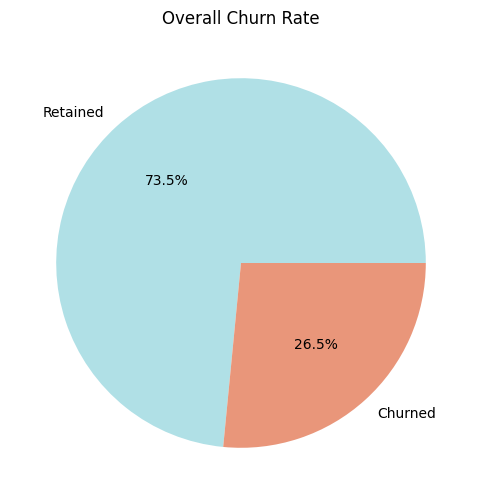

Average tenure and charges by churn:
          tenure  MonthlyCharges
Churn                           
No     37.569965       61.265124
Yes    17.979133       74.441332


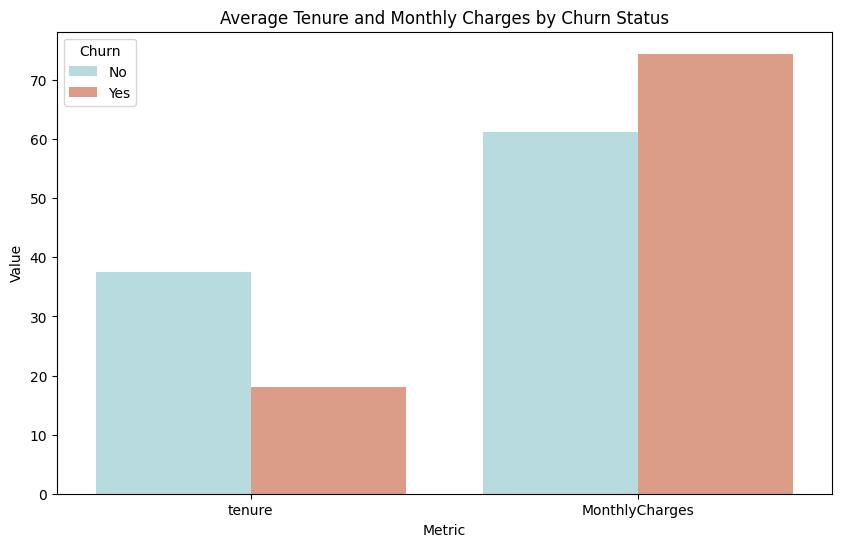

In [11]:
# Overall churn rate
# Calculate overall churn rate
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print("Overall churn rate (%):")
print(churn_rate)

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(churn_rate, labels=['Retained', 'Churned'], autopct='%1.1f%%', colors=['#b0e0e6', '#e9967a'])
plt.title('Overall Churn Rate')
plt.show()

# Calculate average churn by tenure and monthly charges
avg_by_churn = df.groupby('Churn')[['tenure', 'MonthlyCharges']].mean()
print("Average tenure and charges by churn:")
print(avg_by_churn)

# Reshape for plotting
avg_melted = avg_by_churn.reset_index().melt(id_vars='Churn', var_name='Metric', value_name='Value')

# Grouped bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', hue='Churn', data=avg_melted, palette=['#b0e0e6', '#e9967a'])
plt.title('Average Tenure and Monthly Charges by Churn Status')
plt.ylabel('Value')
plt.xlabel('Metric')

plt.show()

Churn rate by contract (%):
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


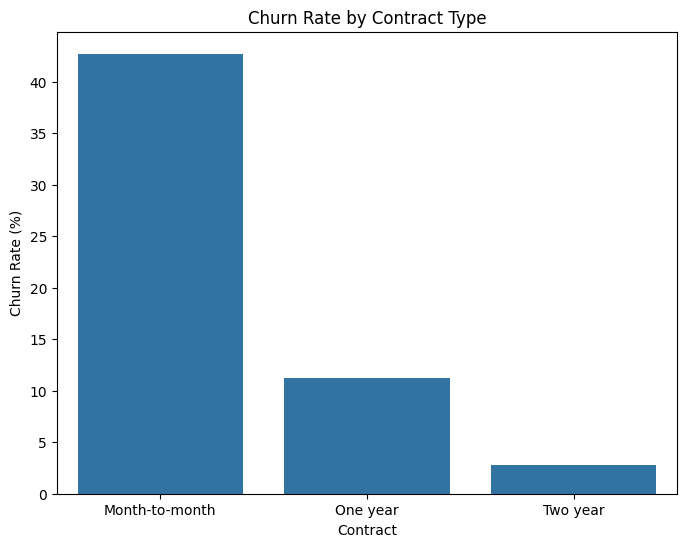

In [13]:

# Churn rate by contract
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print("Churn rate by contract (%):")
print(contract_churn)

# Bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Contract', y='Yes', data=contract_churn.reset_index())
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

Churn rate by tenure group (%):
Churn               No        Yes
TenureGroup                      
0-12         51.715805  48.284195
13-24        70.487106  29.512894
25-36        77.968037  22.031963
37-48        80.481283  19.518717
49-60        85.000000  15.000000
61+          91.703836   8.296164


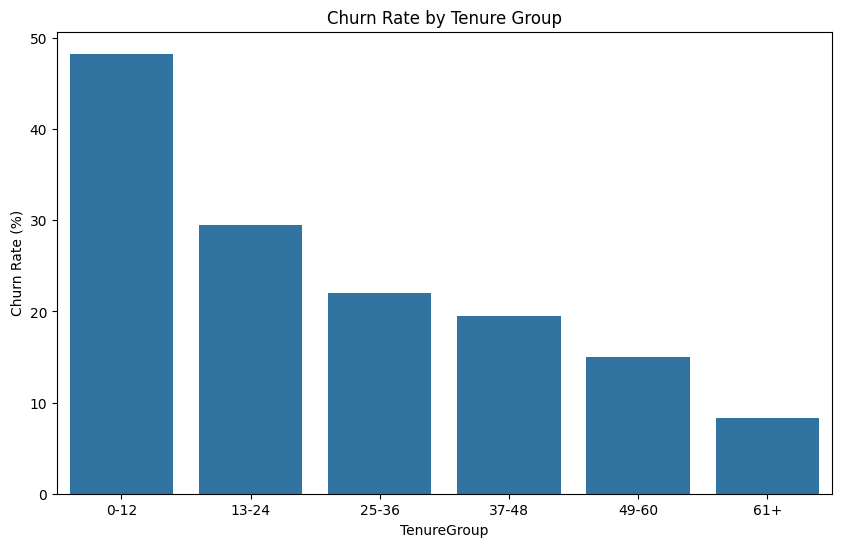

In [69]:
# Churn rate by tenure group
tenure_churn = df.groupby('TenureGroup')['Churn'].value_counts(normalize=True).unstack() * 100
print("Churn rate by tenure group (%):")
print(tenure_churn)

# Bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='TenureGroup', y='Yes', data=tenure_churn.reset_index())
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.show()

Churn rate by payment method (%):
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


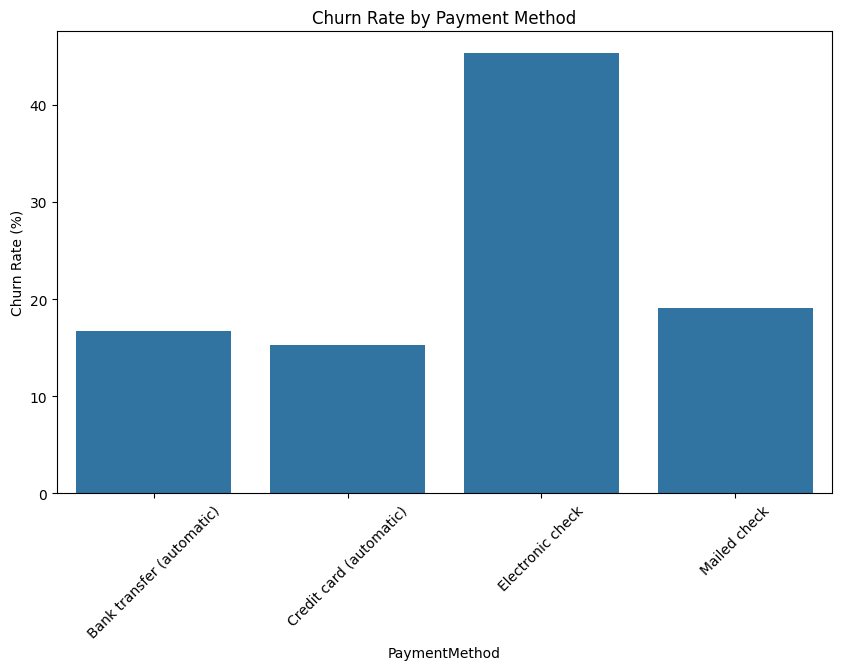

In [79]:
payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100
print("Churn rate by payment method (%):")
print(payment_churn)

plt.figure(figsize=(10, 6))
sns.barplot(x='PaymentMethod', y='Yes', data=payment_churn.reset_index())
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

Cohort-like churn by tenure group (%):
Churn               No        Yes
TenureGroup                      
0-12         51.715805  48.284195
13-24        70.487106  29.512894
25-36        77.968037  22.031963
37-48        80.481283  19.518717
49-60        85.000000  15.000000
61+          91.703836   8.296164


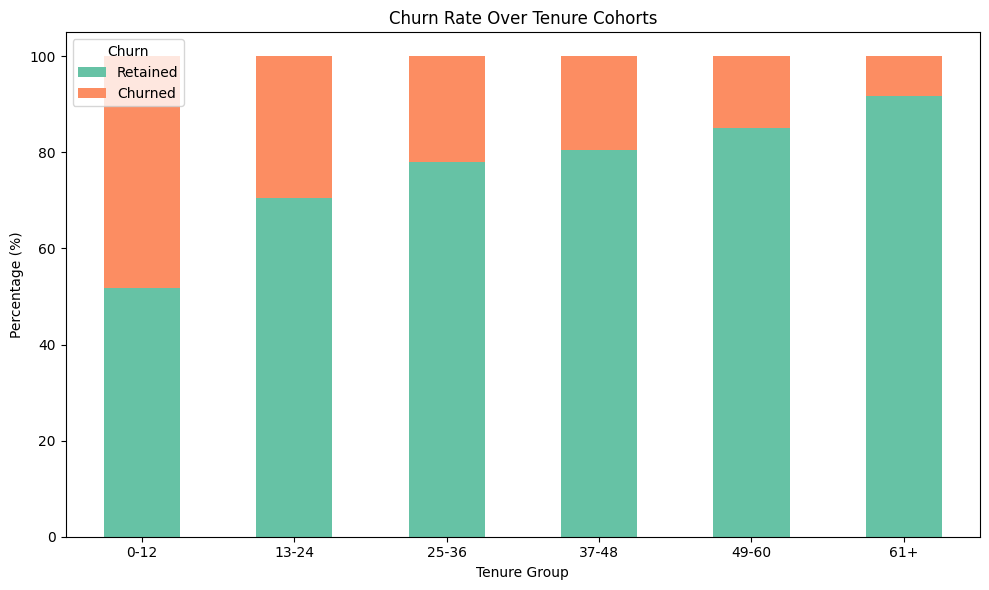

In [75]:
#We don’t have an exact “sign-up month” column,
#but we can calculate cohorts using tenure as a proxy (assuming lower tenure = newer customers).
# Define cohort-like groups based on tenure buckets
cohort_churn = df.groupby('TenureGroup')['Churn'].value_counts(normalize=True).unstack() * 100
print("Cohort-like churn by tenure group (%):")
print(cohort_churn)

# Plot stacked bar chart
cohort_churn.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66c2a5', '#fc8d62'])
plt.title('Churn Rate Over Tenure Cohorts')
plt.xlabel('Tenure Group')
plt.ylabel('Percentage (%)')
plt.legend(title='Churn', labels=['Retained', 'Churned'])
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()